# IT25101857 — Feature Scaling
Technique: Standardization (StandardScaler) of age

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("../data/raw/HAM10000_metadata.csv")

print(df.shape)
df.info()
df.head()

(10015, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [2]:
df['age'] = df['age'].fillna(df['age'].median())

## Why Scaling?

- age ranges roughly 0-100, while one-hot encoded columns (sex, localization) are binary (0/1). Without scaling, distance-based models (SVM, KNN-style logic) would let age dominate the distance calculation purely due to its larger numeric range.

In [3]:
print(df['age'].describe())

count    10015.000000
mean        51.853220
std         16.920833
min          0.000000
25%         40.000000
50%         50.000000
75%         65.000000
max         85.000000
Name: age, dtype: float64


In [4]:
scaler = StandardScaler()
df['age_scaled'] = scaler.fit_transform(df[['age']])

df[['age', 'age_scaled']].describe()

,age,age_scaled
count,10015.000000,1.001500e+04
mean,51.853220,-1.163545e-16
std,16.920833,1.000050e+00
min,0.000000,-3.064613e+00
25%,40.000000,-7.005454e-01
50%,50.000000,-1.095285e-01
75%,65.000000,7.769970e-01
max,85.000000,1.959031e+00


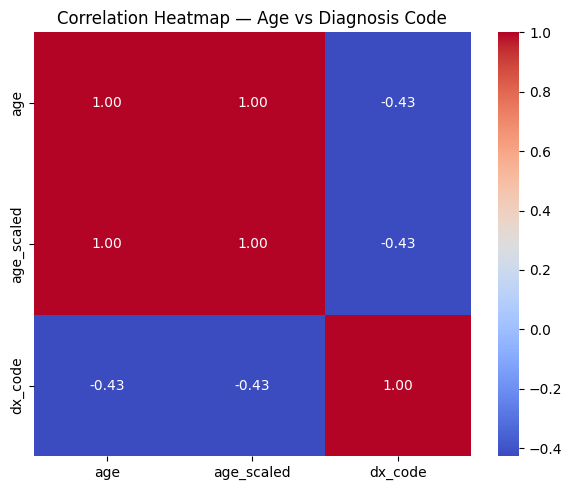

In [5]:
# Encode dx numerically just for correlation purposes (not the final encoding)
df['dx_code'] = df['dx'].astype('category').cat.codes

plt.figure(figsize=(6,5))
corr = df[['age', 'age_scaled', 'dx_code']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap — Age vs Diagnosis Code')
plt.tight_layout()
plt.savefig('../results/eda_visualizations/correlation_heatmap.png', dpi=150)
plt.show()

## Interpretation

As expected, age and age_scaled correlate perfectly (r=1.0) since scaling is a linear transformation. The correlation between age and the diagnosis code is weak, which is an honest early signal that age alone carries limited predictive power for diagnosis class — consistent with the project's stated expectation that metadata-only features will show modest performance.

In [6]:
df.to_csv("../results/outputs/scaling_step_output.csv", index=False)